### Park facilities

The Park facilities data was downloaded from https://data.nashville.gov/datasets/fc380858d6e74ba287ec7fd54965bedf_1/explore?location=36.118568%2C-86.720959%2C11.41

In [10]:
park_fac = pd.read_csv('../data/parks_facilities.csv')
print(park_fac.shape)
park_fac.head(3)

(64, 16)


,GlobalID,Facility Name,Facility Type,Facility Name Abbreviated,Address,City,State,ZipCode,Phone Number,Email,Website,Description,Year Established,OBJECTID,x,y
0,063c1664-d395-4194-9a73-974b6d90f362,East Park Community Center,Community Center,East,"700 Woodland Street, 37206",Nashville,TN,37206.0,(615) 862-8448,NaN,http://www.nashville.gov/Parks-and-Recreation/...,East Park Community Center offers patrons of a...,2007.0,1,1.743596e+06,670361.936567
1,875be7aa-9963-4622-b97f-0d718e00c82e,Hermitage Community Center,Community Center,Hermitage,"3720 James Kay Lane, 37076",Hermitage,TN,37076.0,(615) 316-0843,NaN,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1999.0,2,1.786939e+06,671885.599858
2,968fe30a-28e8-4df8-9309-ed525d7a3621,West Community Center,Community Center,West,"6105 Morrow Road, 37209",Nashville,TN,37209.0,(615) 862-8469,NaN,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1960.0,3,1.713621e+06,667179.798574


In [11]:
park_fac.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GlobalID                   64 non-null     object 
 1   Facility Name              64 non-null     object 
 2   Facility Type              64 non-null     object 
 3   Facility Name Abbreviated  39 non-null     object 
 4   Address                    64 non-null     object 
 5   City                       52 non-null     object 
 6   State                      64 non-null     object 
 7   ZipCode                    54 non-null     float64
 8   Phone Number               64 non-null     object 
 9   Email                      5 non-null      object 
 10  Website                    64 non-null     object 
 11  Description                51 non-null     object 
 12  Year Established           38 non-null     float64
 13  OBJECTID                   64 non-null     int64  
 

In [13]:
park_geo = gpd.GeoDataFrame(park_fac, 
                           crs = zipcodes.crs, 
                           geometry = gpd.points_from_xy(park_fac.x, park_fac.y))
type(park_geo)

geopandas.geodataframe.GeoDataFrame

In [14]:
print(park_geo.crs)
print(zipcodes.crs)

EPSG:4326
EPSG:4326


In [15]:
zipcodes = zipcodes[['zipcode', 'po_name', 'geometry']]

In [16]:
parks_by_zip = gpd.sjoin(park_geo, zipcodes, predicate = 'within')

In [17]:
parks_by_zip.head()

,GlobalID,Facility Name,Facility Type,Facility Name Abbreviated,Address,City,State,ZipCode,Phone Number,Email,Website,Description,Year Established,OBJECTID,x,y,geometry,index_right,zipcode,po_name


In [18]:
parks_by_zip['zipcode'].value_counts()

Series([], Name: count, dtype: int64)

In [19]:
print(park_geo.geometry.geom_type.unique())
print(zipcodes.geometry.geom_type.unique())

['Point']
['Polygon']


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
from folium.plugins import FastMarkerCluster

### Bikeways

The Bikeways data was downloaded from https://datanashvillegov-nashville.hub.arcgis.com/datasets/fdda2da3d1634b63b5ce2696589103d4_0/explore?location=36.127927%2C-86.727866%2C10.52

In [26]:
bikeways = gpd.read_file('../data/bikeways_view.geojson')
print(bikeways.crs)
bikeways.head( )

EPSG:4326


,OBJECTID,BikewayType,Status,OnStreetName,FromStreetName,ToStreetName,YearCompleted,District,geometry
0,1,WOL,Complete,Broadway,3rd Ave S,1st Ave S,2011.0,19,"LINESTRING (-86.77437 36.16225, -86.77597 36.1..."
1,2,BL,Complete,Division St,Buddy Killen Cir,Music Sq E,2004.0,19,"LINESTRING (-86.79191 36.15219, -86.79192 36.1..."
2,3,PBL,Complete,12th Ave S,Lawrence Ave,Division St,2023.0,"17, 18, 19","LINESTRING (-86.78432 36.15108, -86.78454 36.1..."
3,4,BL,Complete,Fort Negley Blvd,Chestnut St,Hamilton Ave,2014.0,17,"LINESTRING (-86.77578 36.14213, -86.77594 36.1..."
4,5,SSR,Completed,Gale Ln,Belmont Blvd,975' SW of 8th Ave S,2024.0,"17, 18","LINESTRING (-86.77650 36.11760, -86.77666 36.1..."


In [27]:
type(bikeways)

geopandas.geodataframe.GeoDataFrame

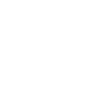

In [28]:
bikeways.loc[0, 'geometry']

In [29]:
print(bikeways.loc[0, 'geometry'])

LINESTRING (-86.7743716768098 36.1622466686255, -86.7759662991622 36.1615556317565)


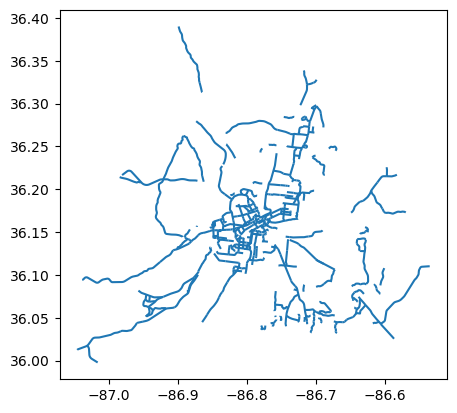

In [30]:
bikeways.plot();

### Park facilities 2

In [11]:
parks_facilities = gpd.read_file('../data/parks_facilities.geojson')
print(parks_facilities.crs)
parks_facilities.head( )

EPSG:4326


,GlobalID,FacilityName,FacilityType,NameAbbrev,Address,City,State,ZipCode,PhoneNumber,Email,Website,Description,YearEstablished,OBJECTID,geometry
0,063c1664-d395-4194-9a73-974b6d90f362,East Park Community Center,Community Center,East,"700 Woodland Street, 37206",Nashville,TN,37206,(615) 862-8448,None,http://www.nashville.gov/Parks-and-Recreation/...,East Park Community Center offers patrons of a...,2007.0,1,POINT (-86.76200 36.17255)
1,875be7aa-9963-4622-b97f-0d718e00c82e,Hermitage Community Center,Community Center,Hermitage,"3720 James Kay Lane, 37076",Hermitage,TN,37076,(615) 316-0843,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1999.0,2,POINT (-86.61518 36.17757)
2,968fe30a-28e8-4df8-9309-ed525d7a3621,West Community Center,Community Center,West,"6105 Morrow Road, 37209",Nashville,TN,37209,(615) 862-8469,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1960.0,3,POINT (-86.86345 36.16312)
3,9fbb14e6-5d89-4ce9-aeba-f0d21baa85f4,Watkins Community Center,Community Center,Watkins,"616 17th Avenue North, 37203",Nashville,TN,37203,(615) 862-8468,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1963.0,4,POINT (-86.80008 36.16243)
4,240e51d1-7581-4e2f-95f1-ea44a49fb389,Kirkpatrick Community Center,Community Center,Kirkpatrick,"620 South 9th Street, 37206",Nashville,TN,37206,(615) 862-8453,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1963.0,5,POINT (-86.75333 36.16814)


In [13]:
type(parks_facilities)

geopandas.geodataframe.GeoDataFrame

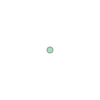

In [14]:
parks_facilities.loc[0, 'geometry']

In [15]:
print(parks_facilities.loc[0, 'geometry'])

POINT (-86.7619961104642 36.172547470931)


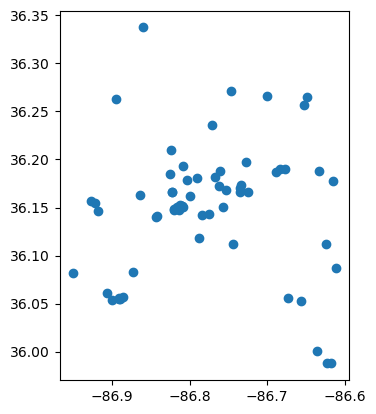

In [16]:
parks_facilities.plot();

In [17]:
parks_facilities_by_zip = gpd.sjoin(parks_facilities, zipcodes, predicate='within')

In [18]:
parks_facilities_by_zip.head()

,GlobalID,FacilityName,FacilityType,NameAbbrev,Address,City,State,ZipCode,PhoneNumber,Email,Website,Description,YearEstablished,OBJECTID,geometry,index_right,zipcode,po_name
0,063c1664-d395-4194-9a73-974b6d90f362,East Park Community Center,Community Center,East,"700 Woodland Street, 37206",Nashville,TN,37206,(615) 862-8448,None,http://www.nashville.gov/Parks-and-Recreation/...,East Park Community Center offers patrons of a...,2007.0,1,POINT (-86.76200 36.17255),1,37206,NASHVILLE
1,875be7aa-9963-4622-b97f-0d718e00c82e,Hermitage Community Center,Community Center,Hermitage,"3720 James Kay Lane, 37076",Hermitage,TN,37076,(615) 316-0843,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1999.0,2,POINT (-86.61518 36.17757),52,37076,HERMITAGE
2,968fe30a-28e8-4df8-9309-ed525d7a3621,West Community Center,Community Center,West,"6105 Morrow Road, 37209",Nashville,TN,37209,(615) 862-8469,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1960.0,3,POINT (-86.86345 36.16312),9,37209,NASHVILLE
3,9fbb14e6-5d89-4ce9-aeba-f0d21baa85f4,Watkins Community Center,Community Center,Watkins,"616 17th Avenue North, 37203",Nashville,TN,37203,(615) 862-8468,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1963.0,4,POINT (-86.80008 36.16243),32,37203,NASHVILLE
4,240e51d1-7581-4e2f-95f1-ea44a49fb389,Kirkpatrick Community Center,Community Center,Kirkpatrick,"620 South 9th Street, 37206",Nashville,TN,37206,(615) 862-8453,None,http://www.nashville.gov/Parks-and-Recreation/...,Metro Parks operates 19 Neighborhood Community...,1963.0,5,POINT (-86.75333 36.16814),1,37206,NASHVILLE


In [19]:
parks_facilities_by_zip['zipcode'].value_counts()

zipcode
37203    12
37221     8
37206     6
37209     5
37013     5
37218     4
37207     4
37214     3
37208     3
37076     2
37080     2
37217     2
37138     2
37211     1
37216     1
37228     1
37115     1
37204     1
37210     1
Name: count, dtype: int64

In [20]:
parks_facilities_in_37203 = parks_facilities_by_zip.loc[parks_facilities_by_zip['zipcode'] == '37203']
parks_facilities_in_37203.shape

(12, 18)

In [21]:
polygon37203 = zipcodes.loc[zipcodes['zipcode'] == '37203']
polygon37203.shape

(1, 3)

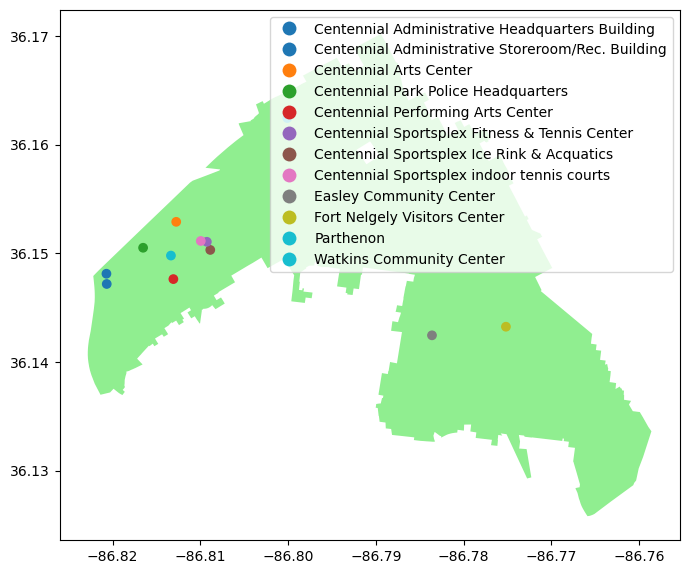

In [22]:
ax = polygon37203.plot(figsize=(8, 10), color='lightgreen')
parks_facilities_in_37203.plot(ax=ax, column='FacilityName', legend=True)
plt.show()

In [23]:
polygon37203.geometry.centroid

C:\Users\PC\AppData\Local\Temp\ipykernel_12156\651956959.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polygon37203.geometry.centroid


32    POINT (-86.78898 36.14857)
dtype: geometry

In [24]:
center = polygon37203.geometry.centroid.iloc[0]
print(center)

POINT (-86.78898421845274 36.14857447700962)


C:\Users\PC\AppData\Local\Temp\ipykernel_12156\35750993.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = polygon37203.geometry.centroid.iloc[0]


In [25]:
area_center = [center.y, center.x]
print(area_center)

[36.14857447700962, -86.78898421845274]


In [26]:
map_37203 = folium.Map(location=area_center, zoom_start=12)
map_37203

In [27]:
map_37203 = folium.Map(location=area_center, zoom_start=12)

folium.GeoJson(polygon37203).add_to(map_37203)

In [34]:
for row_index, row_values in parks_facilities_in_37203.iterrows():
    geom = row_values['geometry']

    if geom.geom_type == 'Point':
        folium.Marker(
            location=[geom.y, geom.x],
            tooltip=row_values.get('FacilityName', 'Unknown'),
            icon=folium.Icon(color="green",icon="tree", prefix='fa')
        ).add_to(map_37203)

In [35]:
map_37203

In [37]:
cluster_map_37203 = folium.Map(location =  area_center, zoom_start = 12)

#create a marker cluster
marker_cluster = MarkerCluster().add_to(cluster_map_37203)

folium.GeoJson(polygon37203).add_to(cluster_map_37203)

# inside the loop add each marker to the cluster
for _, row in parks_facilities_in_37203.iterrows():
    geom = row['geometry']
    name = row.get('FacilityName', 'Unknown')

    if geom.geom_type == 'Point':
        loc = [geom.y, geom.x]
        icon = folium.Icon(color="green", icon="tree", prefix='fa')

        marker = folium.Marker(
            location=loc,
            tooltip=name,
            icon=icon
        )

        marker.add_to(marker_cluster)

    
#save an interactive HTML map by calling .save()
# cluster_map_37207.save('../maps/cluster37207.html')

cluster_map_37203  

In [43]:

map_37203 = folium.Map(location =  area_center, zoom_start = 12)

folium.GeoJson(polygon37203).add_to(map_37203)

#create a list of locations and pass them to FastMarkerCluster()
locations = []

for _, row in parks_facilities_in_37203.iterrows():
    geom = row['geometry']
    if geom.geom_type == 'Point':
        locations.append([geom.y, geom.x])

        
map_37203.add_child(
    FastMarkerCluster(locations)
)

#display our map
map_37203

### Zipcode areas

The zipcode data was downloaded from https://datanashvillegov-nashville.hub.arcgis.com/datasets/Nashville::zip-code-boundaries-1/explore


In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
from folium.plugins import FastMarkerCluster

In [8]:
zipcodes = gpd.read_file('../data/zip_code_boundaries_nashville.geojson')
print(zipcodes.crs)
# zipcodes.head( )

EPSG:4326


In [9]:
columns = {'OBJECTID': 'object_id',
          'ZipCode': 'zipcode',
          'POName': 'po_name',
          'GlobalID': 'global_id'}

zipcodes = zipcodes.rename(columns=columns)
zipcodes.head( )

,object_id,zipcode,po_name,global_id,geometry
0,229,37115,MADISON,9492b2a0-dff5-4e2e-b77b-37c25b5c96f3,"POLYGON ((-86.68725 36.31821, -86.68722 36.318..."
1,230,37206,NASHVILLE,3a287c8d-543c-4f6e-8463-27bf9c3d8356,"POLYGON ((-86.75348 36.16274, -86.75383 36.162..."
2,231,37216,NASHVILLE,c3501fa2-5146-4881-95ac-0f36b9da82af,"POLYGON ((-86.73451 36.23774, -86.73425 36.237..."
3,232,37213,NASHVILLE,b50f3ab3-9571-4457-b059-68ef9bd0b13a,"POLYGON ((-86.77787 36.17706, -86.77810 36.176..."
4,233,37086,LA VERGNE,c3ccae22-29a2-4599-9241-72cddd64a35a,"POLYGON ((-86.58870 36.02671, -86.58837 36.026..."


In [10]:
zipcodes.describe()

,object_id
count,57.000000
mean,257.000000
std,16.598193
min,229.000000
25%,243.000000
50%,257.000000
75%,271.000000
max,285.000000


In [11]:
type(zipcodes)

geopandas.geodataframe.GeoDataFrame

#### Now let's look at the difference between calling the first geometry variable.....


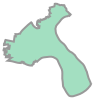

In [12]:
zipcodes.loc[0, 'geometry']

#### ...and printing it


In [13]:
print(zipcodes.loc[0, 'geometry'])

POLYGON ((-86.6872490902623 36.3182121225898, -86.6872165943563 36.3182105624904, -86.6871818213919 36.3182087819047, -86.6871470811249 36.318206919112, -86.6871123058618 36.3182050015336, -86.6870775641674 36.3182029738052, -86.6870428217634 36.3182008640597, -86.6870348093141 36.3182003643403, -86.6870080788765 36.3181986984312, -86.6869733695666 36.318196423554, -86.6869386584338 36.318194066666, -86.686903946584 36.3181916268596, -86.6868692685382 36.3181891039388, -86.6868345563761 36.3181864991906, -86.6867998757988 36.3181838122417, -86.6867652301394 36.3181810421722, -86.6867305492426 36.3181781893804, -86.6866959008102 36.3181752273464, -86.6866612864246 36.3181722101345, -86.6866266713228 36.3181691100044, -86.6865920543993 36.3181659278635, -86.686557437639 36.3181626357625, -86.6865228538202 36.3181592893914, -86.686488270157 36.318155832159, -86.6864537194277 36.3181523197553, -86.6864191668771 36.3181487253409, -86.6863846144826 36.3181450200653, -86.68635009503 36.318141

#### Plotting a GeoDataFrame is as easy as calling the GeoPandas .plot() function


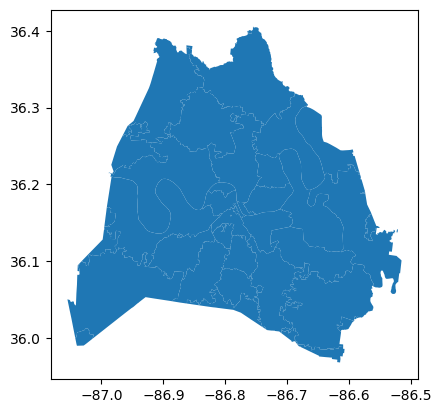

In [14]:
zipcodes.plot();

#### Add information and styling 
- set the `column =` to a column in the GeoDataFrame to color by
- change the [colormap](https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html) 
- pass in keywords to tweak the legend created by [`matplotib`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html)


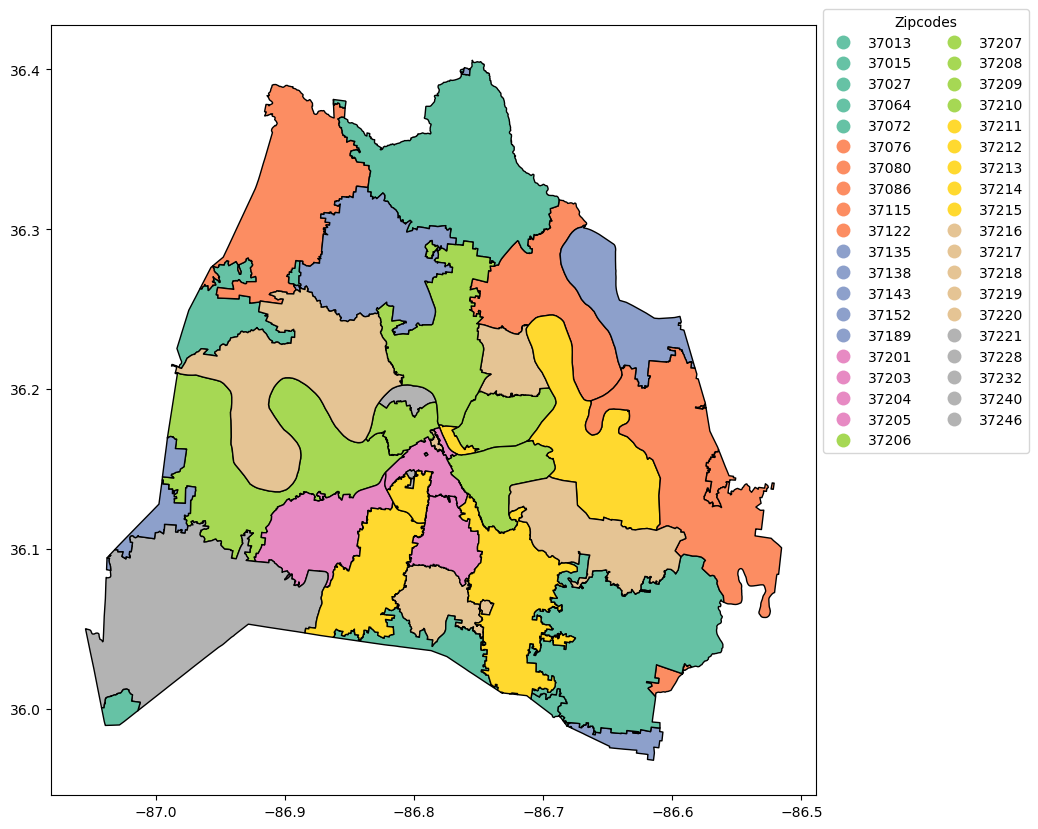

In [15]:
#geopandas will take care of legend styling if you pass a dict of keywords

leg_kwds = {'title': 'Zipcodes', 'loc': 'upper left', 
            'bbox_to_anchor': (1, 1.03), 'ncol': 2}

zipcodes.plot(column = 'zipcode', figsize=(10, 10),
              edgecolor = 'black',
              legend = True, legend_kwds = leg_kwds, 
              cmap = 'Set2')
plt.show()

### Greenways

The Greenways data was downloaded from https://datanashvillegov-nashville.hub.arcgis.com/datasets/66abb12e63e44af9ad0fcd81414e049e_5/explore?location=36.121257%2C-86.763862%2C11.08

In [16]:
greenways = gpd.read_file('../data/greenways.geojson')
print(greenways.crs)
greenways.head( )

EPSG:4326


,GlobalID,Difficulty,SurfaceMaterial,Greenway,GreenwayTrailName,Mileage,Description,OwnedBy,GreenwayType,YearBuilt,OBJECTID,geometry
0,9ab32307-9255-42bb-98b3-bcc9ee9e4577,None,Paved,Mill Creek Greenway,Orchard Bend Park,0.083224,Turner,None,Greenway,NaN,28,"LINESTRING Z (-86.66974 36.02465 0.00000, -86...."
1,05caea61-9112-419e-bb95-70c0284ee52d,,Paved,Cumberland River Greenway,Brookemeade Park,0.364287,"Trail To Kelley's Point, Cumberland River Over...",Metro,Multi-use,2005.0,494,MULTILINESTRING Z ((-86.90419 36.13075 0.00000...
2,09adeb86-5a30-449f-b88f-271c284dad9a,,Paved,Cumberland River Greenway,Downtown,0.650000,Trail connecting the riverfront to Bicentenial...,Metro,Multi-use,2001.0,495,MULTILINESTRING Z ((-86.78201 36.17455 0.00000...
3,569f7bb2-4333-4e31-8c52-471c454aa5a9,,Paved,Cumberland River Greenway,Downtown,0.542944,Rolling Mill Hill overlook. Connects to Ascend...,Metro,Multi-use,2013.0,496,"LINESTRING Z (-86.76469 36.15531 0.00000, -86...."
4,a401702f-5ba2-453c-a4eb-4907e61fa33d,,Paved,Cumberland River Greenway,Metro Center Levee - Catfish Tunnel to Freelan...,1.495068,Main Trail,Metro,Multi-use,2004.0,498,MULTILINESTRING Z ((-86.80091 36.20110 0.00000...


In [17]:
type(greenways)

geopandas.geodataframe.GeoDataFrame

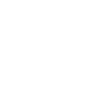

In [18]:
greenways.loc[0, 'geometry']

In [19]:
print(greenways.loc[0, 'geometry'])

LINESTRING Z (-86.6697442831992 36.0246473087091 0, -86.6697198577077 36.0245701901704 0, -86.6697049999639 36.0242977893763 0, -86.6696938520143 36.0241108096183 0, -86.6697029309577 36.0240521787101 0, -86.6698188825318 36.0238774529531 0, -86.6700254831471 36.0235768485816 0)


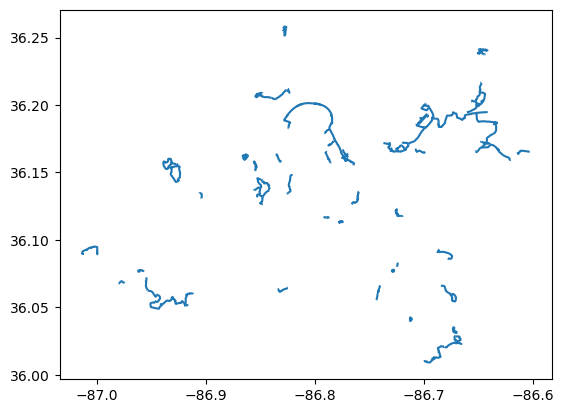

In [20]:
greenways.plot();

### 3

In [21]:
zipcodes = zipcodes[['zipcode', 'po_name', 'geometry']]

In [22]:
greenways_by_zip = gpd.sjoin(greenways, zipcodes, predicate='within')

In [23]:
greenways_by_zip.head()

,GlobalID,Difficulty,SurfaceMaterial,Greenway,GreenwayTrailName,Mileage,Description,OwnedBy,GreenwayType,YearBuilt,OBJECTID,geometry,index_right,zipcode,po_name
0,9ab32307-9255-42bb-98b3-bcc9ee9e4577,None,Paved,Mill Creek Greenway,Orchard Bend Park,0.083224,Turner,None,Greenway,NaN,28,"LINESTRING Z (-86.66974 36.02465 0.00000, -86....",33,37013,ANTIOCH
1,05caea61-9112-419e-bb95-70c0284ee52d,,Paved,Cumberland River Greenway,Brookemeade Park,0.364287,"Trail To Kelley's Point, Cumberland River Over...",Metro,Multi-use,2005.0,494,MULTILINESTRING Z ((-86.90419 36.13075 0.00000...,9,37209,NASHVILLE
4,a401702f-5ba2-453c-a4eb-4907e61fa33d,,Paved,Cumberland River Greenway,Metro Center Levee - Catfish Tunnel to Freelan...,1.495068,Main Trail,Metro,Multi-use,2004.0,498,MULTILINESTRING Z ((-86.80091 36.20110 0.00000...,12,37228,NASHVILLE
5,9b1efe78-2584-4513-9006-d4b9379cb533,,Paved,Cumberland River Greenway,Downtown,0.360000,Connector trail from riverfront to Morgan Park,Metro,Multi-use,2008.0,499,MULTILINESTRING Z ((-86.79030 36.17985 0.00000...,36,37208,NASHVILLE
8,fb9e6442-963e-41e0-abdc-420ba9c4a045,,Paved,Forest Hills Greenway,Percy Priest Elementary Trail,0.687086,Priest School to Robert E. Lee Dr.,Forest Hills,Multi-use,2010.0,502,"LINESTRING Z (-86.83418 36.06373 0.00000, -86....",37,37215,NASHVILLE


In [24]:
greenways_by_zip['zipcode'].value_counts()

zipcode
37206    21
37209    18
37221    15
37214    13
37211    12
37013    12
37218    10
37189     9
37115     7
37203     5
37228     4
37138     4
37201     3
37204     3
37076     2
37205     2
37215     1
37208     1
37213     1
Name: count, dtype: int64

In [25]:
greenways_in_37206 = greenways_by_zip.loc[greenways_by_zip['zipcode'] == '37206']
greenways_in_37206.shape

(21, 15)

In [26]:
polygon37206 = zipcodes.loc[zipcodes['zipcode'] == '37206']
polygon37206.shape

(1, 3)

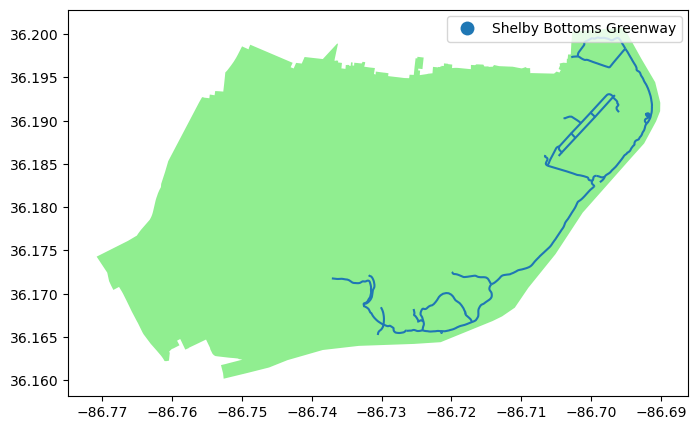

In [27]:
ax = polygon37206.plot(figsize=(8, 10), color='lightgreen')
greenways_in_37206.plot(ax=ax, column='Greenway', legend=True)
plt.show()

In [28]:
polygon37206.geometry.centroid

C:\Users\PC\AppData\Local\Temp\ipykernel_24032\4245166938.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polygon37206.geometry.centroid


1    POINT (-86.73098 36.18090)
dtype: geometry

In [29]:
center = polygon37206.geometry.centroid.iloc[0]
print(center)

POINT (-86.73098318103281 36.180896910667)


C:\Users\PC\AppData\Local\Temp\ipykernel_24032\929099478.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = polygon37206.geometry.centroid.iloc[0]


In [30]:
area_center = [center.y, center.x]
print(area_center)

[36.180896910667, -86.73098318103281]


In [31]:
map_37206 = folium.Map(location=area_center, zoom_start=12)
map_37206

In [32]:
map_37206 = folium.Map(location=area_center, zoom_start=12)

folium.GeoJson(polygon37206).add_to(map_37206)

In [33]:
for row_index, row_values in greenways_in_37206.iterrows():
    geom = row_values['geometry']
    
    if geom.geom_type in ['LineString', 'MultiLineString']:
        folium.GeoJson(
            geom,
            tooltip=row_values['GreenwayTrailName'],
            style_function=lambda x: {'color': 'green', 'weight': 4}
        ).add_to(map_37206)

In [34]:
map_37206

In [35]:
area_center = [36.1627, -86.7816]

In [36]:
map_all = folium.Map(location=area_center, zoom_start=11)

In [37]:
folium.GeoJson(
    zipcodes,
    name="Zipcodes",
    tooltip=folium.GeoJsonTooltip(fields=["zipcode", "po_name"]),
    style_function=lambda feature: {
        'fillColor': '#%06x' % (hash(feature['properties']['zipcode']) % 0xFFFFFF),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.5
    }
).add_to(map_all)

In [38]:
for _, row in greenways.iterrows():
    geom = row['geometry']
    if geom.geom_type in ['LineString', 'MultiLineString']:
        folium.GeoJson(
            geom,
            tooltip=row['GreenwayTrailName'],
            style_function=lambda x: {'color': 'green', 'weight': 3}
        ).add_to(map_all)

In [39]:
# map_all.save('../maps/zipcodes_greenways_stops_clustered.html')
# map_all

In [43]:
print(map_all)